# 🍜 Mid- & Post-Training

[Sam Foreman](https://samforeman.me)
(\[[ALCF](https://alcf.anl.gov/about/people/sam-foreman)\](<https://alcf.anl.gov/about/people/sam-foreman>))  
2026-07-22

> **Authors**
>
> Written by [Sam Foreman](https://samforeman.me) for the [Intro to HPC
> Bootcamp](https://intro-hpc-bootcamp.alcf.anl.gov/).

[](https://colab.research.google.com/github/saforem2/intro-hpc-bootcamp/blob/main/docs/03-advanced-llms/3-mid-post-training/index.ipynb)
[](https://github.com/saforem2/intro-hpc-bootcamp/blob/main/content/03-advanced-llms/3-mid-post-training/index.qmd)

So far you have seen how a model is *pretrained* from scratch (labs
[\[2.0\]](../../02-llms/0-intro-to-llms/index.qmd)–[\[2.2\]](../../02-llms/2-shakespeare-example-colab/index.ipynb))
and how that pretraining is *scaled* across GPUs and nodes ([\[1.4\]
Distributed
Training](../../01-neural-networks/4-distributed-training/index.qmd),
[\[2.1\] Parallel
Training](../../02-llms/1-parallel-training/index.qmd)).

A pretrained **base model** is a very good next-token predictor. It is
*not* yet a chatbot: ask it a question and it will happily continue your
question rather than answer it. Turning a base model into something
useful takes two more stages of training on **much smaller, much
higher-quality** data. That is what this lab is about.

## 🧬 Where this fits in the LLM lifecycle

<figure id="fig-llm-lifecycle">
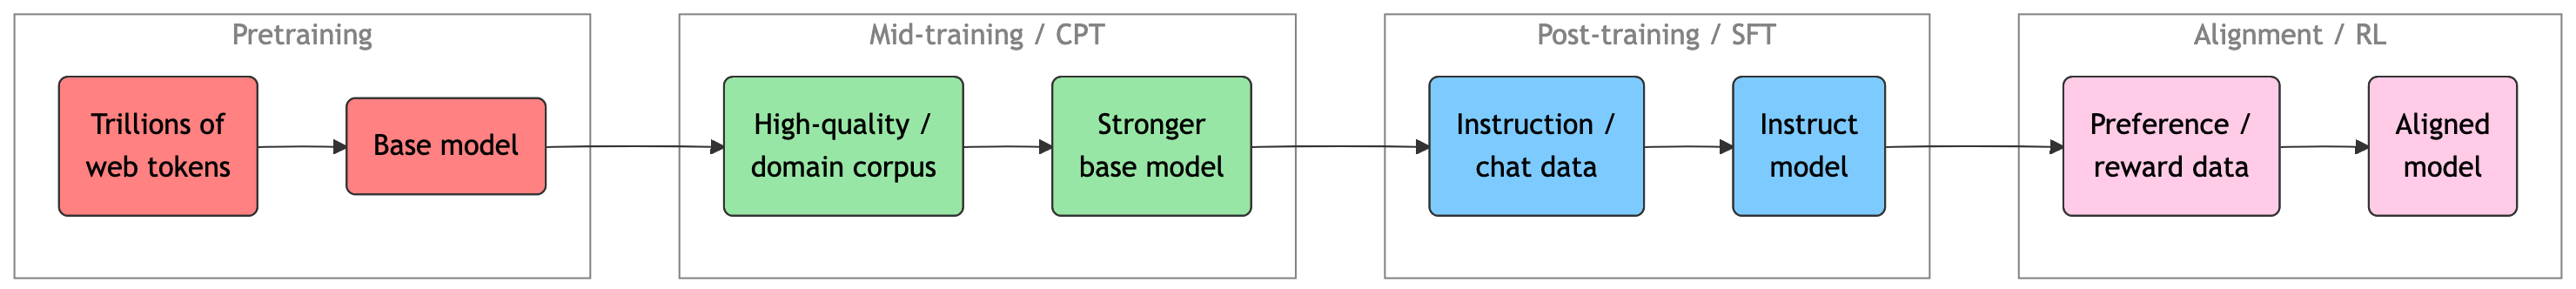
<figcaption>Figure 1: The LLM lifecycle. Each stage uses <strong>less
data</strong> but <strong>higher quality</strong> than the one before
it, and moves the model from “predicts text” toward “does what you
ask.”</figcaption>
</figure>

- **Pretraining** — trillions of tokens of general web text; learns
  language, facts, reasoning primitives. Expensive, done once.
- **Mid-training / CPT** (this lab) — *continue* the same next-token
  objective on a curated, often domain-specific corpus (code, math,
  biomedical text, a new language, your lab’s papers). Cheap relative to
  pretraining, high leverage.
- **Post-training / SFT** (this lab) — teach the model to follow
  instructions and speak in a **chat template** using (prompt,
  completion) pairs.
- **Alignment / RL** — DPO / GRPO / PPO on preference data. Covered in
  the next lab: [\[3.4\] RL &
  Reasoning](../4-rl-and-reasoning/index.qmd).

Throughout we use the HuggingFace [TRL](https://huggingface.co/docs/trl)
and [PEFT](https://huggingface.co/docs/peft) libraries. Together they
are the standard, batteries-included stack for post-training.

> **Render note**
>
> `trl`, `peft`, and `deepspeed` are **not** installed in the site build
> environment, and real fine-tuning needs a GPU. Every cell that touches
> them is marked `#| eval: false` so it renders as copy-pasteable code
> without running. The handful of cells that *do* run use only
> `transformers` + `torch` on CPU with a `gpt2` tokenizer. Flip any
> `eval: false` to `true` on the cluster to run it for real.

## 🧪 ① A toy that really runs

### (a) Continued pretraining (CPT), conceptually

CPT is *the same objective as pretraining* — predict the next token —
just on a better corpus and with a **much smaller learning rate**. The
recipe is deliberately boring:

1.  **Concatenate** your corpus into one long stream of token IDs.
2.  **Chunk** the stream into fixed-length blocks (the context window).
3.  Train the base model on those blocks with a **low LR**.

What makes tokens “high quality”? Roughly: dense in information, low in
boilerplate/spam, deduplicated, and *relevant to what you want the model
to be good at*. A page of careful proofs or clean, well-documented code
teaches the model far more per token than a scraped forum thread.

The data-loading + chunking shape runs on CPU with the `gpt2` tokenizer:

In [2]:
from transformers import AutoTokenizer
import torch

tok = AutoTokenizer.from_pretrained("gpt2")

# A *tiny* stand-in for a high-quality, domain-specific corpus.
corpus = [
    "Argonne's Aurora is an exascale supercomputer at the ALCF.",
    "A tokenizer maps text to integer token IDs that the model can read.",
    "Continued pretraining keeps the language-modeling objective: predict the next token.",
]

# 1. Tokenize + concatenate into one long stream of token IDs
#    (put an end-of-text token between documents).
ids = []
for line in corpus:
    ids.extend(tok(line + tok.eos_token)["input_ids"])
ids = torch.tensor(ids)

# 2. Chunk the stream into fixed-length blocks (the "context window").
block_size = 16
n_blocks = len(ids) // block_size
blocks = ids[: n_blocks * block_size].view(n_blocks, block_size)

# 3. For a causal LM, the labels are just the inputs
#    (the model shifts them by one internally to predict the next token).
inputs, labels = blocks, blocks.clone()
print(f"{len(ids)} tokens -> {tuple(blocks.shape)} (n_blocks, block_size)")

53 tokens -> (3, 16) (n_blocks, block_size)

That `(n_blocks, block_size)` tensor is exactly the shape a
`DataCollator` feeds a `Trainer`. The actual training step loads a
**base model** and runs a standard optimizer loop, which is heavy, so it
is display-only here:

In [3]:
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling,
)

model = AutoModelForCausalLM.from_pretrained("EleutherAI/pythia-160m")  # small base LM

args = TrainingArguments(
    output_dir="cpt-out",
    per_device_train_batch_size=8,
    num_train_epochs=1,
    learning_rate=2e-5,   # << KEY: ~10-100x smaller than pretraining LR
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    bf16=True,
    logging_steps=10,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=high_quality_blocks,             # your chunked corpus
    data_collator=DataCollatorForLanguageModeling(tok, mlm=False),
)
trainer.train()

> **⚠️ Catastrophic forgetting**
>
> CPT’s biggest failure mode is **catastrophic forgetting**: push too
> hard on the new corpus and the model *forgets* its general abilities.
> Two standard defenses:
>
> - **Low learning rate** (and short schedules) — nudge the weights,
>   don’t rewrite them. Note the `2e-5` above vs. a typical pretraining
>   LR of `~3e-4`.
> - **Data mixing** — blend a slice of the *original* pretraining
>   distribution (e.g. 5–30% general web text) into your domain corpus
>   so the model keeps its old skills while gaining new ones.

### (b) Supervised fine-tuning (SFT) with a chat template

SFT teaches the base model to follow instructions. The data is a list of
**(prompt, completion)** pairs — most commonly expressed as a `messages`
list of `{"role", "content"}` turns. Before training, every conversation
is rendered into a single string with **special tokens** that mark turn
boundaries. That rendering is the job of
`tokenizer.apply_chat_template`.

`gpt2` ships without a chat template, so we attach a minimal
[ChatML](https://huggingface.co/docs/transformers/main/en/chat_templating)-style
one to see the mechanics. Real chat models (Qwen, OLMo 2,
Llama-3-Instruct) ship their template inside `tokenizer_config.json`:

In [4]:
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("gpt2")

# A minimal ChatML template (real models ship this for you).
tok.chat_template = (
    "{% for m in messages %}"
    "<|im_start|>{{ m['role'] }}\n{{ m['content'] }}<|im_end|>\n"
    "{% endfor %}"
    "{% if add_generation_prompt %}<|im_start|>assistant\n{% endif %}"
)

messages = [
    {"role": "system", "content": "You are a helpful ALCF assistant."},
    {"role": "user", "content": "What is continued pretraining in one sentence?"},
]

prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
print(prompt)

<|im_start|>system
You are a helpful ALCF assistant.<|im_end|>
<|im_start|>user
What is continued pretraining in one sentence?<|im_end|>
<|im_start|>assistant


The output is the exact string the model trains on. Note how
`add_generation_prompt=True` leaves a dangling
`<|im_start|>assistant\n`. That is the cue that tells the model *“your
turn now.”*

Two ideas make SFT work:

- **Schema.** Each example is either
  `{"prompt": ..., "completion": ...}` or a `{"messages": [...]}` list.
  TRL renders `messages` through the chat template automatically.
- **Loss masking.** During SFT we only compute loss on the
  **assistant’s** tokens (the completion). The system/user prompt tokens
  are masked out with label `-100` so the model learns to *produce*
  answers, not to *parrot* questions.

$$\mathcal{L}_{\text{SFT}} = -\sum_{t \in \text{completion}} \log P_\theta\!\left(y_t \mid y_{<t}\right)$$

That `-100` mask is the whole trick, and it fits in a runnable cell.
Take one rendered example laid out as
`[ prompt tokens | completion tokens ]`, build its label mask, and watch
how the loss changes when we *don’t* mask the prompt:

In [5]:
import torch
import torch.nn.functional as F

# One rendered SFT example as token IDs: [ prompt tokens | completion tokens ]
# (tiny fake vocab so we can read off every position by hand).
prompt_ids     = [5, 8, 2, 9]   # system + user turns, ending in "...assistant\n"
completion_ids = [4, 7, 1]      # the assistant answer we actually want to teach
input_ids = torch.tensor(prompt_ids + completion_ids)

# Loss mask: -100 on the prompt, the real IDs on the completion.
IGNORE = -100
labels = torch.tensor([IGNORE] * len(prompt_ids) + completion_ids)
print("input_ids:", input_ids.tolist())
print("labels:   ", labels.tolist(), "  (-100 = masked, contributes no loss)")
print("scored positions:", (labels != IGNORE).nonzero().flatten().tolist(), "(completion only)")

# Toy "base model": it already parrots the PROMPT perfectly (confident + correct
# there) but is clueless (uniform) on the COMPLETION -- just like a fresh base LM.
vocab = 10
logits = torch.zeros(len(input_ids), vocab)
for i, t in enumerate(prompt_ids):
    logits[i, t] = 10.0   # ~0 loss on prompt tokens

# cross_entropy averages over the UNMASKED positions only.
loss_sft = F.cross_entropy(logits, labels, ignore_index=IGNORE)   # completion only
loss_all = F.cross_entropy(logits, input_ids)                     # prompt NOT masked
print(f"\nSFT loss (prompt masked)  : {loss_sft:.3f}  <- the real training signal")
print(f"loss if prompt NOT masked : {loss_all:.3f}  <- diluted by 'free' prompt tokens")

input_ids: [5, 8, 2, 9, 4, 7, 1]
labels:    [-100, -100, -100, -100, 4, 7, 1]   (-100 = masked, contributes no loss)
scored positions: [4, 5, 6] (completion only)

SFT loss (prompt masked)  : 2.303  <- the real training signal
loss if prompt NOT masked : 0.987  <- diluted by 'free' prompt tokens

Masking makes the loss report *only* what the model still has to learn.
Without it, a model that merely echoes the prompt looks deceptively good
while learning nothing about how to answer.

> **✏️ Exercise**
>
> What happens to `loss_sft` if you set every `completion_ids` position
> in `logits` to be confidently correct too (like the prompt)? What does
> that tell you about a model that has finished SFT?
>
> **Solution.** Add
> `for i, t in enumerate(completion_ids): logits[len(prompt_ids)+i, t] = 10.0`
> before computing the loss, and `loss_sft` drops to ~0. A fully SFT’d
> model assigns high probability to the target completion tokens, so the
> (masked) loss it was trained on goes to zero.

The full fine-tune uses TRL’s `SFTTrainer` plus a **LoRA** adapter from
PEFT. Heavy libraries + GPU, so display-only:

In [6]:
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig
from peft import LoraConfig

# Instruction dataset in `messages` format (see §② for the schema).
dataset = load_dataset("HuggingFaceH4/ultrachat_200k", split="train_sft")

peft_config = LoraConfig(
    r=16,                 # rank of the low-rank update
    lora_alpha=32,        # scaling
    lora_dropout=0.05,
    target_modules="all-linear",
    task_type="CAUSAL_LM",
)

sft_config = SFTConfig(
    output_dir="sft-lora-out",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,          # LoRA tolerates a higher LR than full FT
    num_train_epochs=1,
    bf16=True,
    packing=True,                # pack short samples to fill the context window
    max_length=2048,
    assistant_only_loss=True,    # mask the prompt; train on the completion only
)

trainer = SFTTrainer(
    model="EleutherAI/pythia-410m",   # a base (non-instruct) model
    args=sft_config,
    train_dataset=dataset,
    peft_config=peft_config,          # <- LoRA: attach adapters, freeze the base
)
trainer.train()
trainer.save_model("sft-lora-out")    # saves only the small adapter weights

> **🪶 Why LoRA fits on one node**
>
> Full fine-tuning updates **all** the weights, so you must hold the
> model, its gradients, and optimizer states in memory, often several
> times the model size. **LoRA** ([Hu et al. 2021,
> arXiv:2106.09685](https://arxiv.org/abs/2106.09685)) freezes the
> pretrained weights $W_0$ and learns a tiny low-rank update
> $\Delta W = BA$, where $B \in \mathbb{R}^{d\times r}$,
> $A \in \mathbb{R}^{r\times k}$, and the rank $r \ll d,k$:
>
> $$W = W_0 + \Delta W = W_0 + B A$$
>
> Only $A$ and $B$ are trained (often **\<1%** of the parameters). The
> optimizer state shrinks with them, so a model that needs multiple
> nodes to *fully* fine-tune can be LoRA-tuned on a **single GPU** (or
> one node), and the resulting adapter is only a few MB.

## 🏭 ② The real thing

*(display-only: real production configs and schemas)*

### Anatomy of a real chat template

Instruction models are trained on a strict, tokenized conversation
format. Here is the ChatML layout used by Qwen and (with variations)
most modern chat models. The `<|im_start|>` / `<|im_end|>` markers are
**special tokens** in the model’s vocabulary (single IDs, not
spelled-out text):

``` text
<|im_start|>system
You are a helpful ALCF assistant.<|im_end|>
<|im_start|>user
What is continued pretraining?<|im_end|>
<|im_start|>assistant
CPT continues next-token training on a curated corpus.<|im_end|>
```

Llama 3 uses a different but equivalent scheme with `<|begin_of_text|>`,
`<|start_header_id|>role<|end_header_id|>`, and `<|eot_id|>`. The *idea*
is identical: unambiguous, machine-parseable turn boundaries so the
model always knows whose turn it is. **The template used at inference
must match the one used during SFT**, or quality collapses.

### A real SFT dataset schema

Production SFT datasets store each conversation as a `messages` list,
the exact schema TRL consumes directly:

``` json
{
  "messages": [
    {"role": "system", "content": "You are a careful scientific assistant."},
    {"role": "user", "content": "Summarize the goal of continued pretraining."},
    {"role": "assistant", "content": "To adapt a base model to a new domain by continuing next-token training on high-quality, in-domain text at a low learning rate."}
  ]
}
```

Widely used examples: `HuggingFaceH4/ultrachat_200k`,
`allenai/tulu-3-sft-mixture`, and `teknium/OpenHermes-2.5`.

### What a production CPT data mix looks like

Domain adaptation rarely uses *only* the new domain; the mix is
engineered to add a skill **without forgetting the old ones**:

| Source                       | Share | Why it’s in the mix                  |
|:-----------------------------|:----:|:-----------------------------------|
| Curated domain corpus        |  60%  | The new skill (code / math / papers) |
| High-quality general web     |  25%  | Anti-forgetting anchor               |
| Instruction-style / QA text  |  10%  | Eases the later SFT transition       |
| Deduped multilingual / other |  5%   | Breadth, robustness                  |

Table 1: An illustrative continued-pretraining data mix.

> **🔬 At production scale…**
>
> Frontier post-training operates on a completely different order of
> magnitude:
>
> - **SFT data:** *millions* of curated instructions, heavily filtered
>   and often partly synthetic. Tülu 3
>   ([arXiv:2411.15124](https://arxiv.org/abs/2411.15124)) and OLMo 2
>   ([arXiv:2501.00656](https://arxiv.org/abs/2501.00656)) document the
>   full open recipe — SFT → DPO → RLVR — and the data curation that
>   dominates the final quality.
> - **Full fine-tuning, multi-node.** At scale, teams do *full* SFT (not
>   just LoRA) across many nodes, sharding optimizer state with
>   ZeRO/FSDP. These are exactly the parallelism strategies from
>   [\[1.4\] Distributed
>   Training](../../01-neural-networks/4-distributed-training/index.qmd).
> - **Staged pipelines.** The Llama 3 report
>   ([arXiv:2407.21783](https://arxiv.org/abs/2407.21783)) describes
>   several rounds of SFT interleaved with preference optimization, plus
>   dedicated mid-training phases for long-context and specific
>   capabilities.
>
> The APIs below are the *same* ones you just saw. Only the scale, data,
> and node count change.

## 🚀 ③ Scale it up

On the cluster, run SFT as a plain Python module and let `ezpz` handle
the launch. It auto-detects the scheduler (PBS → `mpiexec`, SLURM →
`srun`) and wires up the distributed environment for you. No
`mpirun -n $NGPUS` bookkeeping.

1.  Set up the environment (system-agnostic):

    ``` bash
    source <(curl -fsSL https://bit.ly/ezpz-utils) && ezpz_setup_env
    uv pip install git+https://github.com/saforem2/ezpz
    # trl>=0.20 for the SFTConfig(assistant_only_loss=..., max_length=...) args used below
    uv pip install "trl>=0.20" "peft>=0.13" "datasets" "accelerate" "deepspeed"
    ```

2.  Confirm the distributed setup works:

    ``` bash
    ezpz test
    ```

3.  Launch multi-GPU / multi-node SFT. `ezpz launch` runs the command
    across every rank of your allocation:

    ``` bash
    ezpz launch python3 -m trl.scripts.sft \
        --model_name_or_path EleutherAI/pythia-410m \
        --dataset_name HuggingFaceH4/ultrachat_200k \
        --learning_rate 2e-4 \
        --per_device_train_batch_size 4 \
        --gradient_accumulation_steps 8 \
        --num_train_epochs 1 \
        --bf16 \
        --packing \
        --use_peft --lora_r 16 --lora_alpha 32 \
        --output_dir sft-lora-out
    ```

4.  For long runs, add fault tolerance (spare nodes + automatic
    failover):

    ``` bash
    ezpz launch --auto-retry --spare-nodes auto \
        python3 -m trl.scripts.sft --model_name_or_path EleutherAI/pythia-410m ...
    ```

> **💡 Tip: node-local data**
>
> Staging your dataset and environment to each node’s local `/tmp`
> avoids hammering the shared filesystem during a long SFT run:
>
> ``` bash
> ezpz yeet ./sft-data --compress --min-success-nodes 1
> ```

## 🎒 Homework

Fine-tune a small **base** model (e.g. `EleutherAI/pythia-410m` or
`Qwen/Qwen2.5-0.5B`) to follow a **custom instruction template** of your
choosing, and submit *proof* of a before/after change in behavior.

Your submission should include:

1.  The **prompt/completion (or `messages`) schema** you trained on, and
    the **chat template** string you applied.
2.  A **before** generation: prompt the raw base model and show it does
    *not* follow instructions cleanly.
3.  An **after** generation: prompt your fine-tuned model with the
    *same* prompt (rendered through the template) and show it now
    follows the instruction.

Where *proof* can be any of:

- The text printed to your terminal during the run (before/after
  generations).
- A path to a logfile from a run on the ALCF filesystems.
- A screenshot of the training curve or generations.
- A url to a [W&B Run](https://wandb.ai) or W&B Report.

> **Hint**
>
> The smallest full loop is: `SFTTrainer` + a `LoraConfig` + a few
> hundred examples in `messages` format. Keep `max_length` small and
> `num_train_epochs=1` so it runs in minutes. Compare
> `model.generate(...)` before vs. after loading the adapter.

## 📚 References

- HuggingFace TRL — [SFT Trainer
  docs](https://huggingface.co/docs/trl/sft_trainer)
- HuggingFace PEFT — [LoRA
  docs](https://huggingface.co/docs/peft/developer_guides/lora)
- Hu et al., *LoRA: Low-Rank Adaptation of Large Language Models* —
  [arXiv:2106.09685](https://arxiv.org/abs/2106.09685)
- Grattafiori et al., *The Llama 3 Herd of Models* —
  [arXiv:2407.21783](https://arxiv.org/abs/2407.21783)
- Lambert et al., *Tülu 3: Pushing Frontiers in Open Language Model
  Post-Training* — [arXiv:2411.15124](https://arxiv.org/abs/2411.15124)
- OLMo Team, *2 OLMo 2 Furious* —
  [arXiv:2501.00656](https://arxiv.org/abs/2501.00656)
- [Chat templating in 🤗
  Transformers](https://huggingface.co/docs/transformers/main/en/chat_templating)
- Next: [\[3.4\] RL & Reasoning](../4-rl-and-reasoning/index.qmd) — DPO
  / GRPO / PPO alignment.

Last updated: 2026-07-27 10:32:49